# Lab Instructions

You are working as an analyst for a consulting agency that has been hired to study and improve productivity at a mid-sized company.  Morale is very low and, after speaking with employees, several common complaints kept coming up:

* New employees complained that more tenured employees were lazy and unproductive.
* More tenured employees complained that the newer employees didn't focus and were therefore unproductive.
* Managers were worried that remote workers might be less productive.
* In-person employees found it impossible to focus and be productive when their desk was in the open plan area.
* Many people said they had so much administrative work to do they could only be truly productive if they worked overtime.
* Everyone complained that there were too many meetings.

The consulting agency carefully collected data on a number of factors including number of years at the company, focus (higher is better), productivity (higher is better), department, meetings per week, and desk location can be found in Employee_productivity.csv.

1. Determine which feature - years at the company, hours worked, or focus - has the strongest linear relationship with productivity.  Show a visualization and calculate R-squared for all three relationships to justify your answer.

2. Build on that linear regression model to determine what other featuers also impact productivity. Using both visualzations and R-squared values, build a model that can predicts employee productivity at this company. Evaluate each feature in the dataset.

3. Write a short (a few sentences) summary of how the different factors in the data relate to employee productivity.  What recommendations would you make so that employees can be as productive as possible?



# Student Answers 

First let's load the dataset. 

In [6]:
# in the folder we have Employee_productivity.csv so we need to laod that one 
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import statsmodels.api as sm

df = pd.read_csv("Employee_productivity.csv")
df.head()

,HoursWorked,FocusScore,ProductivityScore,Department,YearsAtCompany,TeamMeetingsPerWeek,DeskLocation
0,42.4,6.3,3127.96,Engineering,17,0,Open Plan
1,34.0,7.2,4742.60,HR,8,6,Private Office
2,47.2,5.6,2044.73,Sales,15,3,Remote
3,38.4,9.0,5818.92,HR,5,6,Private Office
4,36.4,2.5,1841.31,Sales,9,6,Remote


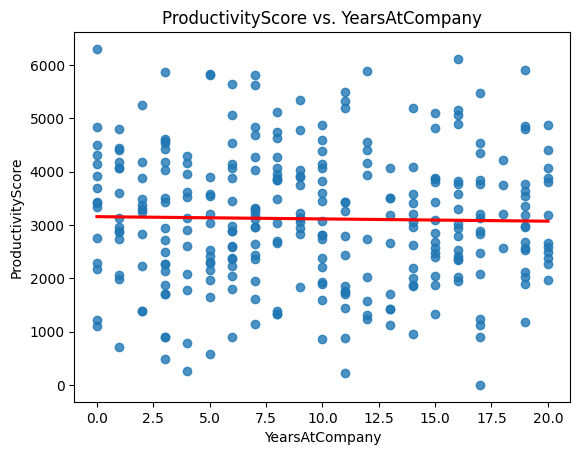

YearsAtCompany → R² = 0.000


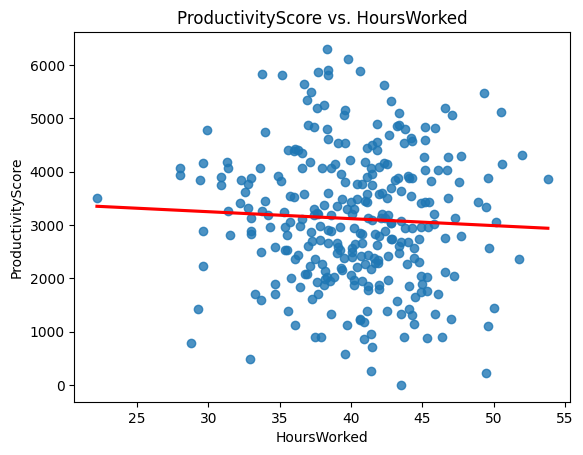

HoursWorked → R² = 0.003


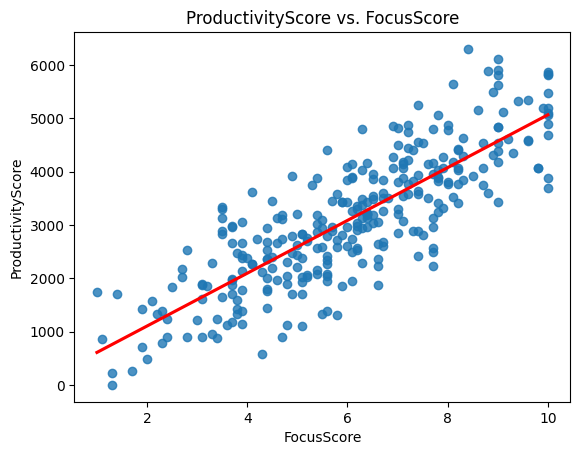

FocusScore → R² = 0.678


In [25]:
#Then since we need to do the same for all three we can do a function and since all three things we are comparing are numeric we can use scatterplots

def findR2_and_plotgraphs(specific_feature):
    # scatterplot
    sns.regplot(x=df[specific_feature], y=df["ProductivityScore"], ci=None, line_kws={"color":"red"})
    plt.title(f"ProductivityScore vs. {specific_feature}")
    plt.show()

    # R² calculation
    X = sm.add_constant(df[[specific_feature]].astype(float).values)   # ensure numeric array
    y = df["ProductivityScore"].astype(float).values
    model = sm.OLS(y, X).fit()
    print(f"{specific_feature} → R² = {model.rsquared:.3f}")

for f in ["YearsAtCompany", "HoursWorked", "FocusScore"]:
    findR2_and_plotgraphs(f)

Let's ingest these results 

1. YearsAtCompany vs ProductivityScore

    The R² = 0.000

    The scatter is flat and random showing no linear relationship.
    Years at the company does not explain productivity.


2. HoursWorked vs ProductivityScore

    The R² = 0.003

    Almost flat with no meaningful relationship.
    Working more or fewer hours doesn’t predict productivity here.


3. FocusScore vs ProductivityScore

    The R² = 0.678
    This scatter shows an upward trend and so far is the best choice for the strongest linear relationship with productivity. This means that an employee’s productivity is not related to how long they’ve worked at the company or how many hours they put in but rather to their level of focus.

# Now lets look at the other features

In [48]:
import pandas as pd
import statsmodels.formula.api as smf

df_ = df.copy()
for c in ["ProductivityScore","FocusScore","HoursWorked","YearsAtCompany","TeamMeetingsPerWeek"]:
    df_[c] = pd.to_numeric(df_[c], errors="coerce")
df_["DeskLocation"] = df_["DeskLocation"].astype(str).str.strip()
df_["Department"]   = df_["Department"].astype(str).str.strip()

# Drop rows needed for any model in this step
df_ = df_.dropna(subset=["ProductivityScore","FocusScore","HoursWorked","YearsAtCompany",
                         "TeamMeetingsPerWeek","DeskLocation","Department"])

def r2(model): 
    return round(model.rsquared, 3)

# 1 using just focus 
m1 = smf.ols('ProductivityScore ~ FocusScore', data=df_).fit()
print("Focus only → R²:", r2(m1))

# 2  then adding  + Hours + Years
m2 = smf.ols('ProductivityScore ~ FocusScore + HoursWorked + YearsAtCompany', data=df_).fit()
print("Focus + HoursWorked + YearsAtCompany → R²:", r2(m2))

# 3 then adding  + Meetings + Desk (set a reference category for readability)
m3 = smf.ols(
    'ProductivityScore ~ FocusScore + HoursWorked + YearsAtCompany + TeamMeetingsPerWeek'
    ' + C(DeskLocation, Treatment(reference="Open Plan"))',
    data=df_
).fit()
print("Prev + Meetings + DeskLocation → R²:", r2(m3))

# 4 add Department 
m4 = smf.ols(
    'ProductivityScore ~ FocusScore + HoursWorked + YearsAtCompany + TeamMeetingsPerWeek'
    ' + C(DeskLocation, Treatment(reference="Open Plan"))'
    ' + C(Department)',
    data=df_
).fit()
print("All features → R²:", r2(m4))
print(m4.summary())  # full table w/ coefficients & p-values


Focus only → R²: 0.678
Focus + HoursWorked + YearsAtCompany → R²: 0.678
Prev + Meetings + DeskLocation → R²: 0.684
All features → R²: 0.685
                            OLS Regression Results                            
Dep. Variable:      ProductivityScore   R-squared:                       0.685
Model:                            OLS   Adj. R-squared:                  0.675
Method:                 Least Squares   F-statistic:                     70.11
Date:                Sun, 21 Sep 2025   Prob (F-statistic):           1.53e-67
Time:                        18:16:54   Log-Likelihood:                -2390.8
No. Observations:                 300   AIC:                             4802.
Df Residuals:                     290   BIC:                             4839.
Df Model:                           9                                         
Covariance Type:            nonrobust                                         
                                                                      

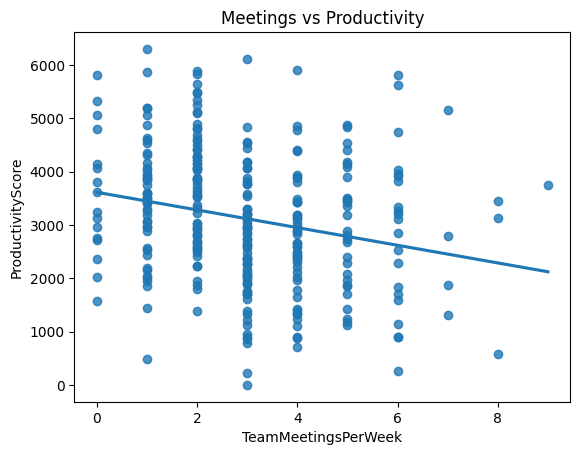

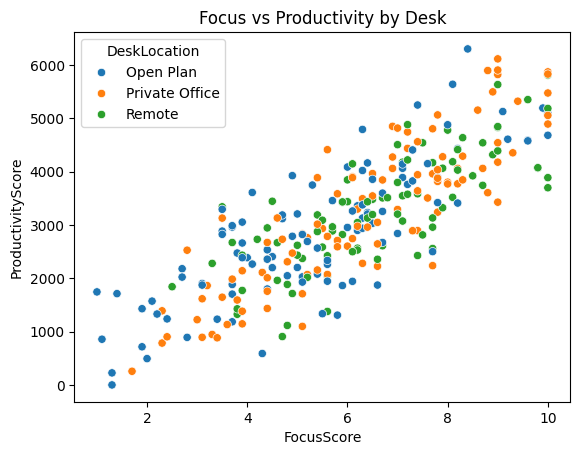

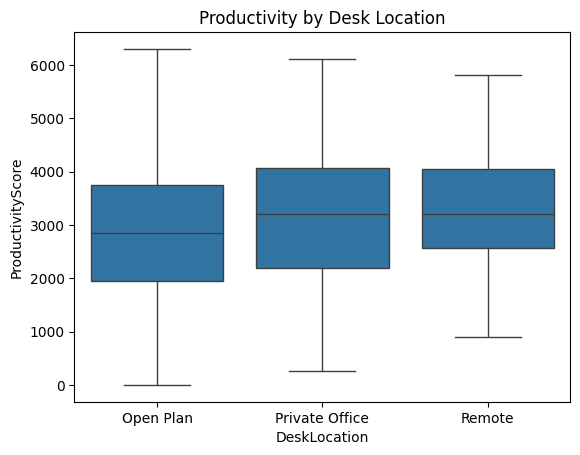

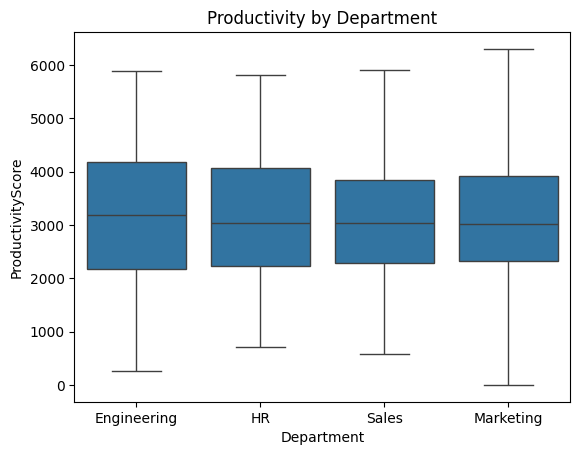

In [53]:
import seaborn as sns, matplotlib.pyplot as plt

sns.regplot(x="TeamMeetingsPerWeek", y="ProductivityScore", data=df_, ci=None)
plt.title("Meetings vs Productivity"); plt.show()

sns.scatterplot(x="FocusScore", y="ProductivityScore", hue="DeskLocation", data=df_)
plt.title("Focus vs Productivity by Desk"); plt.show()

sns.boxplot(x="DeskLocation", y="ProductivityScore", data=df_)
plt.title("Productivity by Desk Location"); plt.show()

sns.boxplot(x="Department", y="ProductivityScore", data=df_)
plt.title("Productivity by Department"); plt.show()


# So what does this all mean? 

Given the data this shows that focus is by far the strongest driver of productivity. Hours worked and years at the company add little  power and means that working longer or simply having more tenure does not make employees more productive. Meetings have a negative effect because the number of meetings per week increases productivity declines. Desk location seems to also matters with open-plan employees generally performing better than those working remotely or in private offices. Departmental differences are minimal and not meaningful.

To improve productivity, the company should prioritize practices that support employee focus, like reducing distractions. Cutting down on unnecessary meetings would also provide measurable benefits. Finally, the company should rethink workspace design and remote work policies, ensuring employees have access to environments that help them stay engaged and effective (according to the data).